<a href="https://colab.research.google.com/github/2026444-Gabriel/Strategic-Think/blob/main/Hotel_Booking_Cancellation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hotel Booking Cancellation Prediction")

Hotel Booking Cancellation Prediction


In [ ]:
# Import the Pandas library
import pandas as pd

# Import the operating system library
import os

# Display the files available in the Colab environment
print(os.listdir('/content'))

['.config', 'H2.csv', 'sample_data']


In [ ]:
# Load the hotel booking dataset
df = pd.read_csv('/content/H2.csv')

# Display the number of rows and columns
print(df.shape)

(79330, 31)


In [ ]:
# Display the first five rows of the dataset
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0.0,...,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03
1,1,88,2015,July,27,1,0,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30
3,1,92,2015,July,27,1,2,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23
4,1,100,2015,July,27,2,0,2,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02


In [ ]:
# Display all column names in the dataset
for column in df.columns:
    print(column)

IsCanceled
LeadTime
ArrivalDateYear
ArrivalDateMonth
ArrivalDateWeekNumber
ArrivalDateDayOfMonth
StaysInWeekendNights
StaysInWeekNights
Adults
Children
Babies
Meal
Country
MarketSegment
DistributionChannel
IsRepeatedGuest
PreviousCancellations
PreviousBookingsNotCanceled
ReservedRoomType
AssignedRoomType
BookingChanges
DepositType
Agent
Company
DaysInWaitingList
CustomerType
ADR
RequiredCarParkingSpaces
TotalOfSpecialRequests
ReservationStatus
ReservationStatusDate


In [ ]:
# Count the number of missing values in each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
print(missing_values[missing_values > 0])

Children     4
Country     24
dtype: int64


In [ ]:
# Display the data type of each column
print(df.dtypes)

IsCanceled                       int64
LeadTime                         int64
ArrivalDateYear                  int64
ArrivalDateMonth                object
ArrivalDateWeekNumber            int64
ArrivalDateDayOfMonth            int64
StaysInWeekendNights             int64
StaysInWeekNights                int64
Adults                           int64
Children                       float64
Babies                           int64
Meal                            object
Country                         object
MarketSegment                   object
DistributionChannel             object
IsRepeatedGuest                  int64
PreviousCancellations            int64
PreviousBookingsNotCanceled      int64
ReservedRoomType                object
AssignedRoomType                object
BookingChanges                   int64
DepositType                     object
Agent                           object
Company                         object
DaysInWaitingList                int64
CustomerType             

In [ ]:
# Count the number of cancelled and non-cancelled reservations
cancellation_counts = df['IsCanceled'].value_counts()

# Display the counts
print(cancellation_counts)

IsCanceled
0    46228
1    33102
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of each cancellation class
cancellation_percentages = df['IsCanceled'].value_counts(normalize=True) * 100

# Display the percentages
print(cancellation_percentages)

IsCanceled
0    58.273037
1    41.726963
Name: proportion, dtype: float64


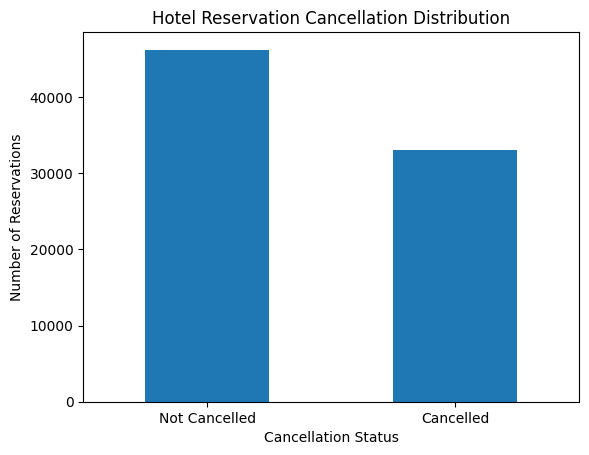

In [ ]:
import matplotlib.pyplot as plt

# Count cancelled and non-cancelled reservations
cancellation_counts = df['IsCanceled'].value_counts()

# Create the bar chart
cancellation_counts.plot(kind='bar')

# Add chart title and labels
plt.title('Hotel Reservation Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Reservations')

# Replace numeric labels with meaningful labels
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'], rotation=0)

# Display the chart
plt.show()

In [ ]:
# Calculate the average lead time for each cancellation group
lead_time_analysis = df.groupby('IsCanceled')['LeadTime'].mean()

# Display the results
print(lead_time_analysis)

IsCanceled
0     80.702734
1    150.281222
Name: LeadTime, dtype: float64


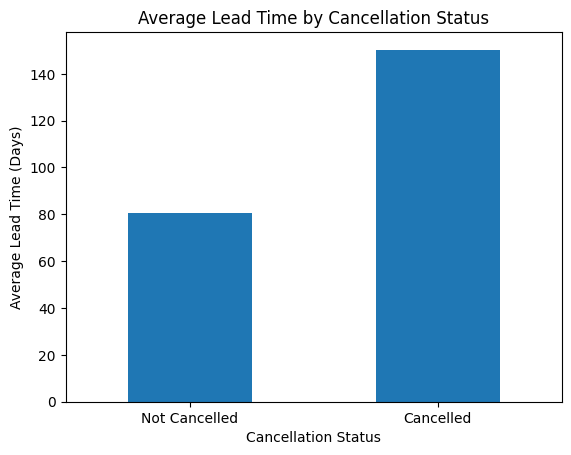

In [ ]:
import matplotlib.pyplot as plt

# Calculate the average lead time for each cancellation group
lead_time_analysis = df.groupby('IsCanceled')['LeadTime'].mean()

# Create a bar chart
lead_time_analysis.plot(kind='bar')

# Add chart title and labels
plt.title('Average Lead Time by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Average Lead Time (Days)')

# Replace numeric labels with meaningful labels
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'], rotation=0)

# Display the chart
plt.show()

In [ ]:
# Create a cross-tabulation between deposit type and cancellation status
deposit_analysis = pd.crosstab(
    df['DepositType'],
    df['IsCanceled']
)

# Display the results
print(deposit_analysis)

IsCanceled           0      1
DepositType                  
No Deposit       46198  20244
Non Refund          24  12844
Refundable           6     14


In [ ]:
# Calculate the cancellation rate for each deposit type
deposit_cancellation_rate = (
    df.groupby('DepositType')['IsCanceled']
    .mean()
    * 100
)

# Display the cancellation rate
print(deposit_cancellation_rate)

DepositType
No Deposit         30.468679
Non Refund         99.813491
Refundable         70.000000
Name: IsCanceled, dtype: float64


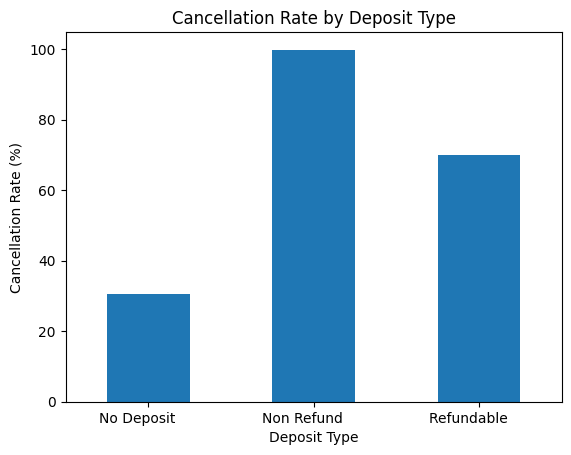

In [ ]:
# Calculate the cancellation rate for each deposit type
deposit_cancellation_rate = (
    df.groupby('DepositType')['IsCanceled']
    .mean()
    * 100
)

# Create a bar chart
deposit_cancellation_rate.plot(kind='bar')

# Add chart title and labels
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

# Keep the category names horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [ ]:
# Create a cross-tabulation between market segment and cancellation status
market_segment_analysis = pd.crosstab(
    df['MarketSegment'],
    df['IsCanceled']
)

# Display the results
print(market_segment_analysis)

IsCanceled         0      1
MarketSegment              
Aviation         185     52
Complementary    478     64
Corporate       2345    641
Direct          5037   1056
Groups          4352   9623
Offline TA/TO   9574   7173
Online TA      24257  14491
Undefined          0      2


In [ ]:
# Calculate the cancellation rate for each market segment
market_segment_cancellation_rate = (
    df.groupby('MarketSegment')['IsCanceled']
    .mean()
    * 100
)

# Display the cancellation rates
print(market_segment_cancellation_rate)

MarketSegment
Aviation          21.940928
Complementary     11.808118
Corporate         21.466845
Direct            17.331364
Groups            68.858676
Offline TA/TO     42.831552
Online TA         37.398059
Undefined        100.000000
Name: IsCanceled, dtype: float64


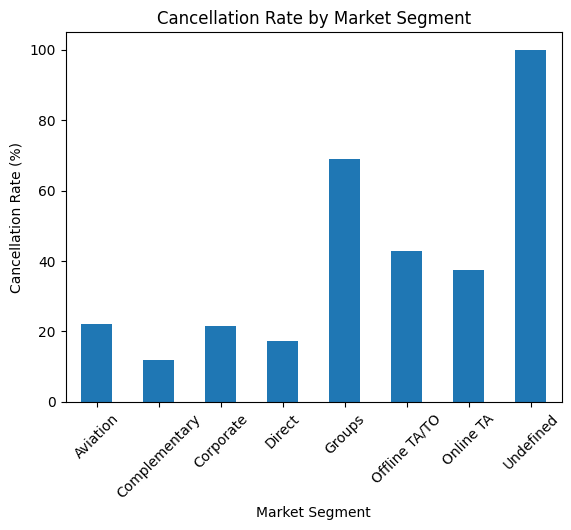

In [ ]:
# Create a bar chart of cancellation rates by market segment
market_segment_cancellation_rate.plot(kind='bar')

# Add chart title and labels
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')

# Rotate the labels slightly for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [ ]:
# Calculate the average ADR for each cancellation group
adr_analysis = df.groupby('IsCanceled')['ADR'].mean()

# Display the results
print(adr_analysis)

IsCanceled
0    105.745948
1    104.687920
Name: ADR, dtype: float64


In [ ]:
# Calculate the average number of adults for each cancellation group
adults_analysis = df.groupby('IsCanceled')['Adults'].mean()

# Display the results
print(adults_analysis)

IsCanceled
0    1.828113
1    1.882907
Name: Adults, dtype: float64


In [ ]:
# Calculate the average number of weekday nights for each cancellation group
weekday_stay_analysis = df.groupby('IsCanceled')['StaysInWeekNights'].mean()

# Display the results
print(weekday_stay_analysis)

IsCanceled
0    2.122934
1    2.266781
Name: StaysInWeekNights, dtype: float64


In [ ]:
# Calculate the average number of weekend nights for each cancellation group
weekend_stay_analysis = df.groupby('IsCanceled')['StaysInWeekendNights'].mean()

# Display the results
print(weekend_stay_analysis)

IsCanceled
0    0.800684
1    0.787505
Name: StaysInWeekendNights, dtype: float64


In [ ]:
# Calculate the total number of nights for each reservation
df['TotalStayNights'] = (
    df['StaysInWeekendNights'] +
    df['StaysInWeekNights']
)

# Display the first five values
print(df['TotalStayNights'].head())

0    2
1    4
2    4
3    6
4    2
Name: TotalStayNights, dtype: int64


In [ ]:
# Calculate the average total stay for each cancellation group
total_stay_analysis = df.groupby('IsCanceled')['TotalStayNights'].mean()

# Display the results
print(total_stay_analysis)

IsCanceled
0    2.923618
1    3.054287
Name: TotalStayNights, dtype: float64


In [ ]:
# Count the different reservation status categories
reservation_status_counts = df['ReservationStatus'].value_counts()

# Display the results
print(reservation_status_counts)

ReservationStatus
Check-Out    46228
Canceled     32186
No-Show        916
Name: count, dtype: int64


In [ ]:
# Define the columns that should not be used as prediction features
columns_to_exclude = [
    'IsCanceled',
    'ReservationStatus',
    'ReservationStatusDate'
]

# Display the columns that will be excluded
print(columns_to_exclude)

['IsCanceled', 'ReservationStatus', 'ReservationStatusDate']


In [ ]:
# Count the unique values in the Agent column
agent_unique_values = df['Agent'].nunique()

# Count the unique values in the Company column
company_unique_values = df['Company'].nunique()

# Display the number of unique values
print("Unique Agent values:", agent_unique_values)
print("Unique Company values:", company_unique_values)

Unique Agent values: 224
Unique Company values: 208


In [ ]:
# Count missing values in the Agent column
agent_missing = df['Agent'].isnull().sum()

# Count missing values in the Company column
company_missing = df['Company'].isnull().sum()

# Display the number of missing values
print("Missing Agent values:", agent_missing)
print("Missing Company values:", company_missing)

Missing Agent values: 0
Missing Company values: 0


In [ ]:
# Count the most common Agent values
print("Top Agent values:")
print(df['Agent'].value_counts().head(10))

# Count the most common Company values
print("\nTop Company values:")
print(df['Company'].value_counts().head(10))

Top Agent values:
Agent
   9    31955
NULL     8131
   1     7137
  14     3640
   7     3539
   6     2683
  28     1666
   3     1308
   8     1236
  37     1230
Name: count, dtype: int64

Top Company values:
Company
NULL    75641
  40      924
  67      267
  45      250
 153      215
 219      141
 233      114
 174      113
  51       86
 242       61
Name: count, dtype: int64


In [ ]:
# Check how many Agent and Company values are stored as the text "NULL"
agent_null = (df['Agent'] == 'NULL').sum()
company_null = (df['Company'] == 'NULL').sum()

print("Agent values stored as 'NULL':", agent_null)
print("Company values stored as 'NULL':", company_null)

Agent values stored as 'NULL': 0
Company values stored as 'NULL': 0


In [ ]:
# Display the data type of the Agent and Company columns
print("Agent data type:", df['Agent'].dtype)
print("Company data type:", df['Company'].dtype)

# Display the most common Agent values including missing values
print("\nAgent values including missing values:")
print(df['Agent'].value_counts(dropna=False).head(10))

# Display the most common Company values including missing values
print("\nCompany values including missing values:")
print(df['Company'].value_counts(dropna=False).head(10))

Agent data type: object
Company data type: object

Agent values including missing values:
Agent
   9    31955
NULL     8131
   1     7137
  14     3640
   7     3539
   6     2683
  28     1666
   3     1308
   8     1236
  37     1230
Name: count, dtype: int64

Company values including missing values:
Company
NULL    75641
  40      924
  67      267
  45      250
 153      215
 219      141
 233      114
 174      113
  51       86
 242       61
Name: count, dtype: int64


In [ ]:
# Compare cancellation rates for reservations with and without Agent information
agent_cancellation = df.groupby(
    df['Agent'].isna()
)['IsCanceled'].mean() * 100

print("Cancellation rate by Agent availability:")
print(agent_cancellation)

# Compare cancellation rates for reservations with and without Company information
company_cancellation = df.groupby(
    df['Company'].isna()
)['IsCanceled'].mean() * 100

print("\nCancellation rate by Company availability:")
print(company_cancellation)

Cancellation rate by Agent availability:
Agent
False    41.726963
Name: IsCanceled, dtype: float64

Cancellation rate by Company availability:
Company
False    41.726963
Name: IsCanceled, dtype: float64


In [ ]:
# Display the exact Python types and representations of Agent values
print("Agent examples:")
for value in df['Agent'].drop_duplicates().head(10):
    print(repr(value), type(value))

print("\nCompany examples:")
for value in df['Company'].drop_duplicates().head(10):
    print(repr(value), type(value))


Agent examples:
'          6' <class 'str'>
'          9' <class 'str'>
'          1' <class 'str'>
'          8' <class 'str'>
'         13' <class 'str'>
'         11' <class 'str'>
'          7' <class 'str'>
'         15' <class 'str'>
'       NULL' <class 'str'>
'         27' <class 'str'>

Company examples:
'       NULL' <class 'str'>
'         40' <class 'str'>
'         45' <class 'str'>
'         38' <class 'str'>
'          9' <class 'str'>
'         47' <class 'str'>
'         49' <class 'str'>
'         51' <class 'str'>
'         48' <class 'str'>
'         62' <class 'str'>


In [ ]:
# Remove leading and trailing spaces from text columns
text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    df[column] = df[column].str.strip()

# Display Agent and Company values after cleaning
print("Agent values after cleaning:")
print(df['Agent'].value_counts().head(10))

print("\nCompany values after cleaning:")
print(df['Company'].value_counts().head(10))

Agent values after cleaning:
Agent
9       31955
NULL     8131
1        7137
14       3640
7        3539
6        2683
28       1666
3        1308
8        1236
37       1230
Name: count, dtype: int64

Company values after cleaning:
Company
NULL    75641
40        924
67        267
45        250
153       215
219       141
233       114
174       113
51         86
242        61
Name: count, dtype: int64


In [ ]:
# Compare cancellation rates for Agent values
agent_cancellation = df.groupby('Agent')['IsCanceled'].mean() * 100

print("Cancellation rate for selected Agent values:")
print(agent_cancellation.loc[
    agent_cancellation.index.isin(['NULL', '9', '1', '14', '7', '6'])
])

# Compare cancellation rates for Company values
company_cancellation = df.groupby('Company')['IsCanceled'].mean() * 100

print("\nCancellation rate for selected Company values:")
print(company_cancellation.loc[
    company_cancellation.index.isin(['NULL', '40', '67', '45', '153'])
])

Cancellation rate for selected Agent values:
Agent
1       73.280090
14      17.912088
6       36.004473
7       13.393614
9       41.502112
NULL    32.087074
Name: IsCanceled, dtype: float64

Cancellation rate for selected Company values:
Company
153     22.325581
40       8.333333
45      11.200000
67      65.543071
NULL    42.725506
Name: IsCanceled, dtype: float64


In [ ]:
# Define the variables that may be available at the time of booking
features = [
    'LeadTime',
    'ArrivalDateYear',
    'ArrivalDateMonth',
    'ArrivalDateWeekNumber',
    'ArrivalDateDayOfMonth',
    'StaysInWeekendNights',
    'StaysInWeekNights',
    'TotalStayNights',
    'Adults',
    'Children',
    'Babies',
    'Meal',
    'Country',
    'MarketSegment',
    'DistributionChannel',
    'IsRepeatedGuest',
    'PreviousCancellations',
    'PreviousBookingsNotCanceled',
    'ReservedRoomType',
    'DepositType',
    'Agent',
    'CustomerType',
    'ADR',
    'RequiredCarParkingSpaces'
]

# Display the selected features
print("Number of features:", len(features))
print("\nSelected features:")
for feature in features:
    print("-", feature)

Number of features: 24

Selected features:
- LeadTime
- ArrivalDateYear
- ArrivalDateMonth
- ArrivalDateWeekNumber
- ArrivalDateDayOfMonth
- StaysInWeekendNights
- StaysInWeekNights
- TotalStayNights
- Adults
- Children
- Babies
- Meal
- Country
- MarketSegment
- DistributionChannel
- IsRepeatedGuest
- PreviousCancellations
- PreviousBookingsNotCanceled
- ReservedRoomType
- DepositType
- Agent
- CustomerType
- ADR
- RequiredCarParkingSpaces


In [ ]:
# Define the target variable
target = 'IsCanceled'

# Display the target variable
print("Target variable:", target)

Target variable: IsCanceled


In [ ]:
# Check missing values in the selected features
missing_features = df[features].isnull().sum()

# Display only columns with missing values
print(missing_features[missing_features > 0])

Children     4
Country     24
dtype: int64


In [ ]:
# Replace missing Children values with 0
df['Children'] = df['Children'].fillna(0)

# Replace missing Country values with "Unknown"
df['Country'] = df['Country'].fillna('Unknown')

# Check that the missing values have been handled
print("Missing Children values:", df['Children'].isnull().sum())
print("Missing Country values:", df['Country'].isnull().sum())

Missing Children values: 0
Missing Country values: 0


In [ ]:
# Identify categorical features
categorical_features = df[features].select_dtypes(include='object').columns

# Display the categorical features
print("Categorical features:")
for feature in categorical_features:
    print("-", feature)

# Display the number of unique categories for each categorical feature
print("\nNumber of unique categories:")
for feature in categorical_features:
    print(feature, ":", df[feature].nunique())


Categorical features:
- ArrivalDateMonth
- Meal
- Country
- MarketSegment
- DistributionChannel
- ReservedRoomType
- DepositType
- Agent
- CustomerType

Number of unique categories:
ArrivalDateMonth : 12
Meal : 4
Country : 167
MarketSegment : 8
DistributionChannel : 5
ReservedRoomType : 8
DepositType : 3
Agent : 224
CustomerType : 4


In [ ]:
# Define the features for the first machine learning model
features = [
    'LeadTime',
    'ArrivalDateYear',
    'ArrivalDateMonth',
    'StaysInWeekendNights',
    'StaysInWeekNights',
    'TotalStayNights',
    'Adults',
    'Children',
    'Babies',
    'Meal',
    'Country',
    'MarketSegment',
    'DistributionChannel',
    'IsRepeatedGuest',
    'PreviousCancellations',
    'PreviousBookingsNotCanceled',
    'ReservedRoomType',
    'DepositType',
    'CustomerType',
    'ADR',
    'RequiredCarParkingSpaces'
]

# Define the target variable
target = 'IsCanceled'

# Display the number of selected features
print("Number of selected features:", len(features))

Number of selected features: 21


In [ ]:
# Create the input features
X = df[features]

# Create the target variable
y = df[target]

# Display the shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (79330, 21)
y shape: (79330,)


In [ ]:
# Import the function used to split the dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of the training and testing sets
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (63464, 21)
Testing set: (15866, 21)


In [ ]:
# Define the numerical features
numerical_features = [
    'LeadTime',
    'ArrivalDateYear',
    'StaysInWeekendNights',
    'StaysInWeekNights',
    'TotalStayNights',
    'Adults',
    'Children',
    'Babies',
    'IsRepeatedGuest',
    'PreviousCancellations',
    'PreviousBookingsNotCanceled',
    'ADR',
    'RequiredCarParkingSpaces'
]

# Define the categorical features
categorical_features = [
    'ArrivalDateMonth',
    'Meal',
    'Country',
    'MarketSegment',
    'DistributionChannel',
    'ReservedRoomType',
    'DepositType',
    'CustomerType'
]

# Display the number of features in each group
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 8


In [ ]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

# Fit the preprocessor using only the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Display the resulting shapes
print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (63464, 218)
Processed testing data: (15866, 218)


In [ ]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the processed training data
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_logistic[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0]


In [ ]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)

# Fit the preprocessor using only the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Display the resulting shapes
print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (63464, 218)
Processed testing data: (15866, 218)


In [ ]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model using the processed training data
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_logistic[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0]


In [ ]:
# Import classification evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

# Display the results
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy:  0.7806
Precision: 0.8217
Recall:    0.6056
F1-score:  0.6973


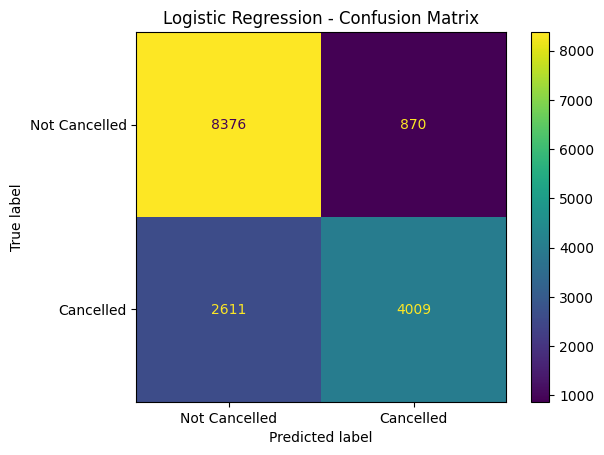

In [ ]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Cancelled', 'Cancelled']
)

disp.plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [ ]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model using the processed training data
decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Make predictions using the Decision Tree model
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_tree[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]


In [ ]:
# Calculate the evaluation metrics for the Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Display the results
print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy:  {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall:    {recall_tree:.4f}")
print(f"F1-score:  {f1_tree:.4f}")

Decision Tree Performance
-------------------------
Accuracy:  0.7693
Precision: 0.9976
Recall:    0.4480
F1-score:  0.6184


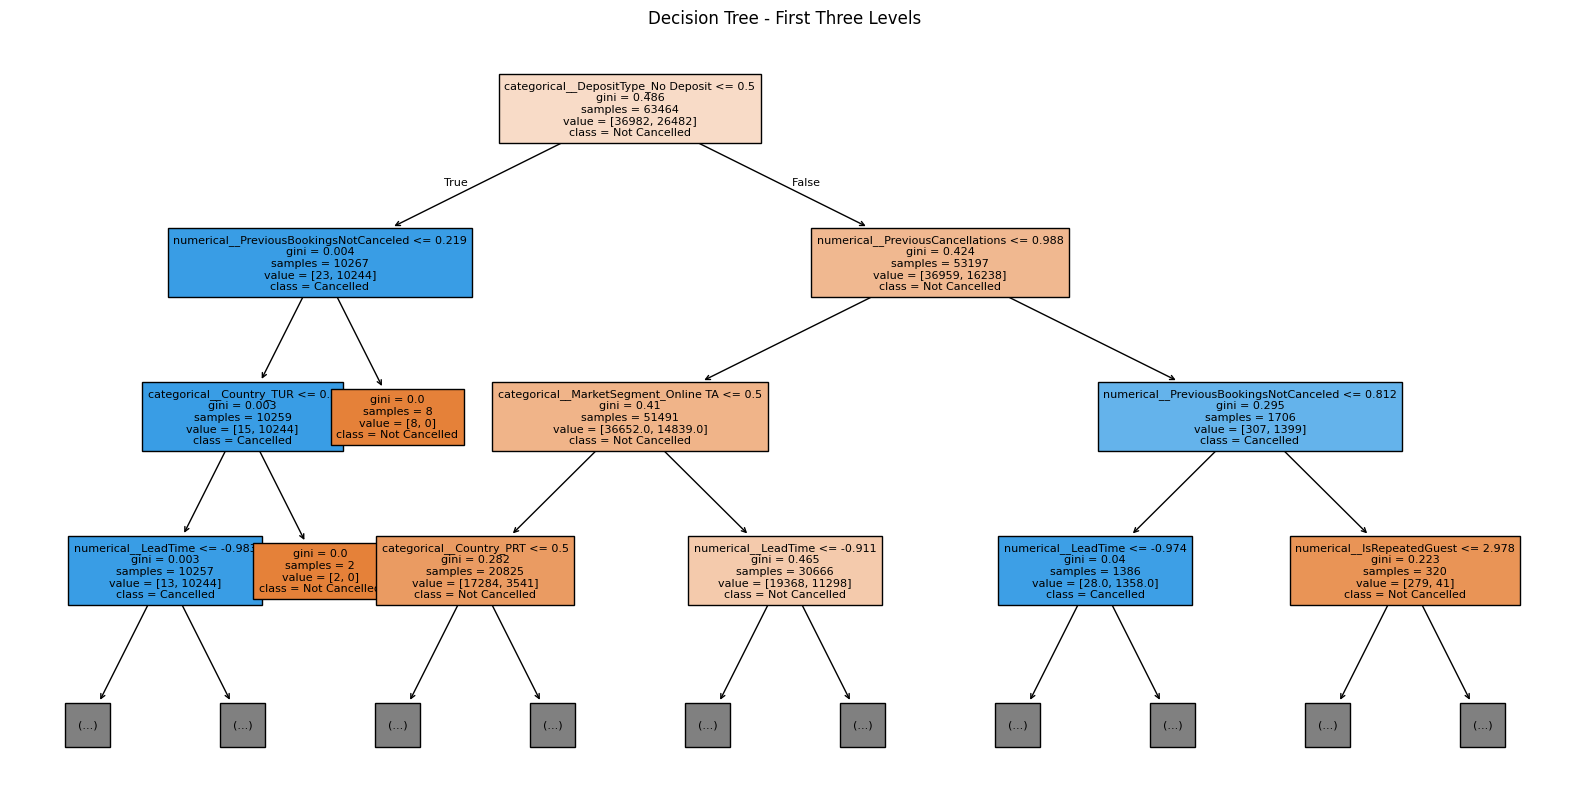

In [ ]:
# Import tools for visualizing the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a figure for the Decision Tree
plt.figure(figsize=(20, 10))

# Plot the first levels of the tree
plot_tree(
    decision_tree_model,
    max_depth=3,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['Not Cancelled', 'Cancelled'],
    fontsize=8
)

plt.title('Decision Tree - First Three Levels')
plt.show()

In [ ]:
# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get the feature importance values from the Decision Tree
importance_values = decision_tree_model.feature_importances_

# Create a DataFrame with feature names and importance values
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display the 15 most important features
print(feature_importance.head(15))

                                    Feature  Importance
198     categorical__DepositType_No Deposit    0.642442
183    categorical__MarketSegment_Online TA    0.075980
205                     numerical__LeadTime    0.075849
214        numerical__PreviousCancellations    0.072709
141                categorical__Country_PRT    0.068869
215  numerical__PreviousBookingsNotCanceled    0.030593
203     categorical__CustomerType_Transient    0.026752
180       categorical__MarketSegment_Direct    0.003945
213              numerical__IsRepeatedGuest    0.001096
216                          numerical__ADR    0.000509
66                 categorical__Country_FRA    0.000485
163                categorical__Country_TUR    0.000310
177     categorical__MarketSegment_Aviation    0.000252
55                 categorical__Country_DEU    0.000207
10    categorical__ArrivalDateMonth_October    0.000000


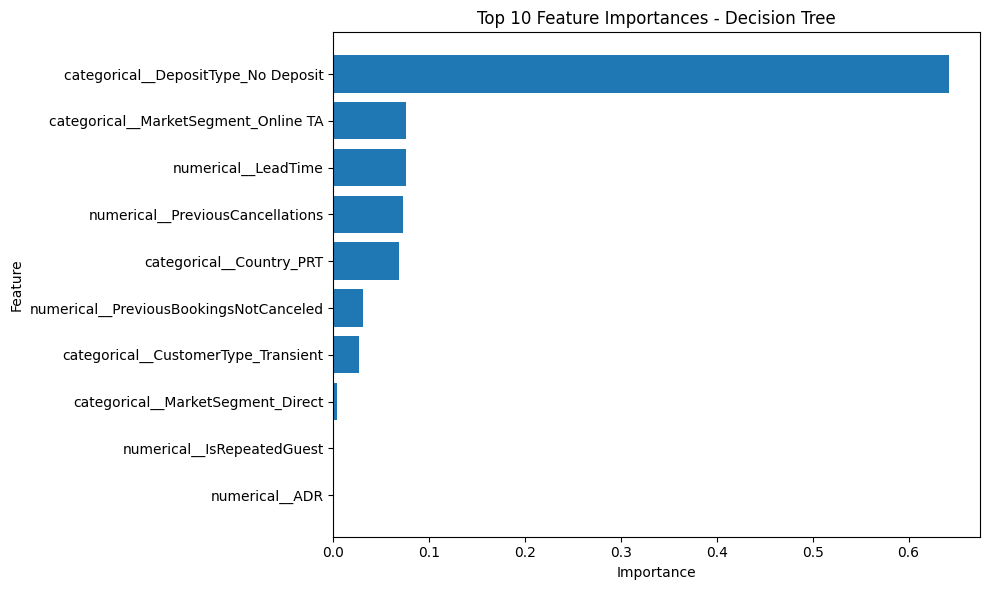

In [ ]:
# Select the 10 most important features
top_features = feature_importance.head(10)

# Create a bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model
random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Make predictions using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_rf[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]


In [ ]:
# Calculate the evaluation metrics for the Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display the results
print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")

Random Forest Performance
-------------------------
Accuracy:  0.7726
Precision: 0.9980
Recall:    0.4559
F1-score:  0.6259


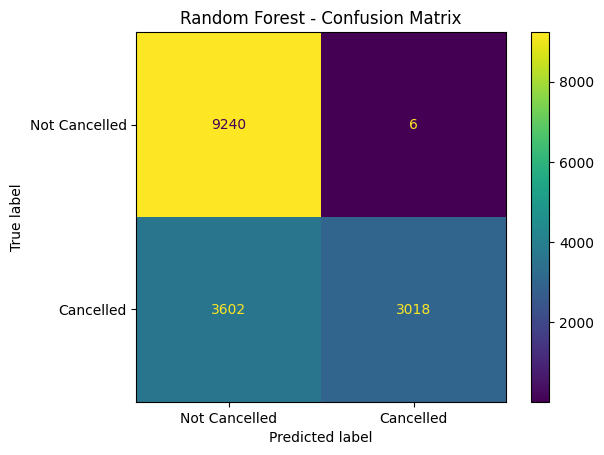

In [ ]:
# Calculate the confusion matrix for the Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not Cancelled', 'Cancelled']
)

disp_rf.plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [ ]:
# Count the actual and predicted classes
print("Actual class distribution:")
print(y_test.value_counts())

print("\nRandom Forest predicted class distribution:")
print(pd.Series(y_pred_rf).value_counts())

Actual class distribution:
IsCanceled
0    9246
1    6620
Name: count, dtype: int64

Random Forest predicted class distribution:
0    12842
1     3024
Name: count, dtype: int64


In [ ]:
# Compare deposit types in the test dataset
deposit_test = pd.crosstab(
    X_test['DepositType'],
    y_test,
    normalize='index'
) * 100

# Display cancellation percentages by deposit type
print(deposit_test)

IsCanceled           0          1
DepositType                      
No Deposit   69.754624  30.245376
Non Refund    0.191058  99.808942
Refundable   50.000000  50.000000


In [ ]:
# Create a balanced Random Forest model
random_forest_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the balanced Random Forest model
random_forest_balanced.fit(X_train_processed, y_train)

print("Balanced Random Forest model trained successfully.")

Balanced Random Forest model trained successfully.


In [ ]:
# Make predictions using the balanced Random Forest
y_pred_rf_balanced = random_forest_balanced.predict(X_test_processed)

# Display the predicted class distribution
print("Balanced Random Forest predicted class distribution:")
print(pd.Series(y_pred_rf_balanced).value_counts())

Balanced Random Forest predicted class distribution:
0    11348
1     4518
Name: count, dtype: int64


In [ ]:
# Calculate the evaluation metrics for the balanced Random Forest
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)
precision_rf_balanced = precision_score(y_test, y_pred_rf_balanced)
recall_rf_balanced = recall_score(y_test, y_pred_rf_balanced)
f1_rf_balanced = f1_score(y_test, y_pred_rf_balanced)

# Display the results
print("Balanced Random Forest Performance")
print("---------------------------------")
print(f"Accuracy:  {accuracy_rf_balanced:.4f}")
print(f"Precision: {precision_rf_balanced:.4f}")
print(f"Recall:    {recall_rf_balanced:.4f}")
print(f"F1-score:  {f1_rf_balanced:.4f}")

Balanced Random Forest Performance
---------------------------------
Accuracy:  0.7967
Precision: 0.8756
Recall:    0.5976
F1-score:  0.7104


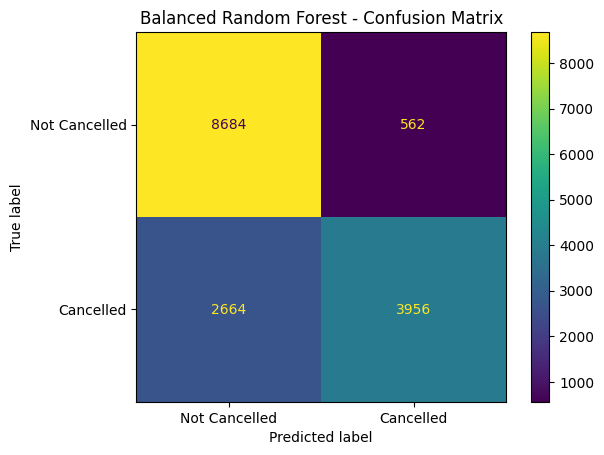

In [ ]:
# Calculate the confusion matrix for the balanced Random Forest
cm_rf_balanced = confusion_matrix(y_test, y_pred_rf_balanced)

# Display the confusion matrix
disp_rf_balanced = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_balanced,
    display_labels=['Not Cancelled', 'Cancelled']
)

disp_rf_balanced.plot()
plt.title('Balanced Random Forest - Confusion Matrix')
plt.show()

In [13]:
# Check the physical number of lines in the CSV file
!wc -l /content/H2.csv

79331 /content/H2.csv


In [14]:
!ls -lh /content/H2.csv

-rw-r--r-- 1 root root 16M Oct  1 02:44 /content/H2.csv


In [15]:
!tail -5 /content/H2.csv

0,23,2017,August,35,30,2,5,2,0,0,BB       ,BEL,Offline TA/TO,TA/TO,              0,0,0,A               ,A               ,0,No Deposit     ,        394,       NULL,0,Transient,96.14,0,0,Check-Out,2017-09-06
0,102,2017,August,35,31,2,5,3,0,0,BB       ,FRA,Online TA,TA/TO,              0,0,0,E               ,E               ,0,No Deposit     ,          9,       NULL,0,Transient,225.43,0,2,Check-Out,2017-09-07
0,34,2017,August,35,31,2,5,2,0,0,BB       ,DEU,Online TA,TA/TO,              0,0,0,D               ,D               ,0,No Deposit     ,          9,       NULL,0,Transient,157.71,0,4,Check-Out,2017-09-07
0,109,2017,August,35,31,2,5,2,0,0,BB       ,GBR,Online TA,TA/TO,              0,0,0,A               ,A               ,0,No Deposit     ,         89,       NULL,0,Transient,104.4,0,0,Check-Out,2017-09-07
0,205,2017,August,35,29,2,7,2,0,0,HB       ,DEU,Online TA,TA/TO,              0,0,0,A               ,A               ,0,No Deposit     ,          9,       NULL,0,Transient,151.2,0,2,Ch

In [16]:
# Reload the hotel booking dataset
df = pd.read_csv('/content/H2.csv')

# Display the number of rows and columns
print(df.shape)

(79330, 31)


In [17]:
print(df.shape)
print(df.columns.tolist())

(79330, 31)
['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateMonth', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children', 'Babies', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'ReservedRoomType', 'AssignedRoomType', 'BookingChanges', 'DepositType', 'Agent', 'Company', 'DaysInWaitingList', 'CustomerType', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'ReservationStatus', 'ReservationStatusDate']


In [18]:
# Calculate the total number of nights for each reservation
df['TotalStayNights'] = (
    df['StaysInWeekendNights'] +
    df['StaysInWeekNights']
)

# Display the first five values
print(df['TotalStayNights'].head())

0    2
1    4
2    4
3    6
4    2
Name: TotalStayNights, dtype: int64


In [19]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

# Display only columns with missing values
print(missing_values[missing_values > 0])

Children     4
Country     24
dtype: int64


In [20]:
# Create a comparison table for all machine learning models
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Balanced Random Forest'
    ],
    'Accuracy': [
        0.7806,
        0.7693,
        0.7726,
        0.7967
    ],
    'Precision': [
        0.8217,
        0.9976,
        0.9980,
        0.8756
    ],
    'Recall': [
        0.6056,
        0.4480,
        0.4559,
        0.5976
    ],
    'F1-Score': [
        0.6973,
        0.6184,
        0.6259,
        0.7104
    ]
})

# Display the comparison table
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7806,0.8217,0.6056,0.6973
1,Decision Tree,0.7693,0.9976,0.4480,0.6184
2,Random Forest,0.7726,0.9980,0.4559,0.6259
3,Balanced Random Forest,0.7967,0.8756,0.5976,0.7104


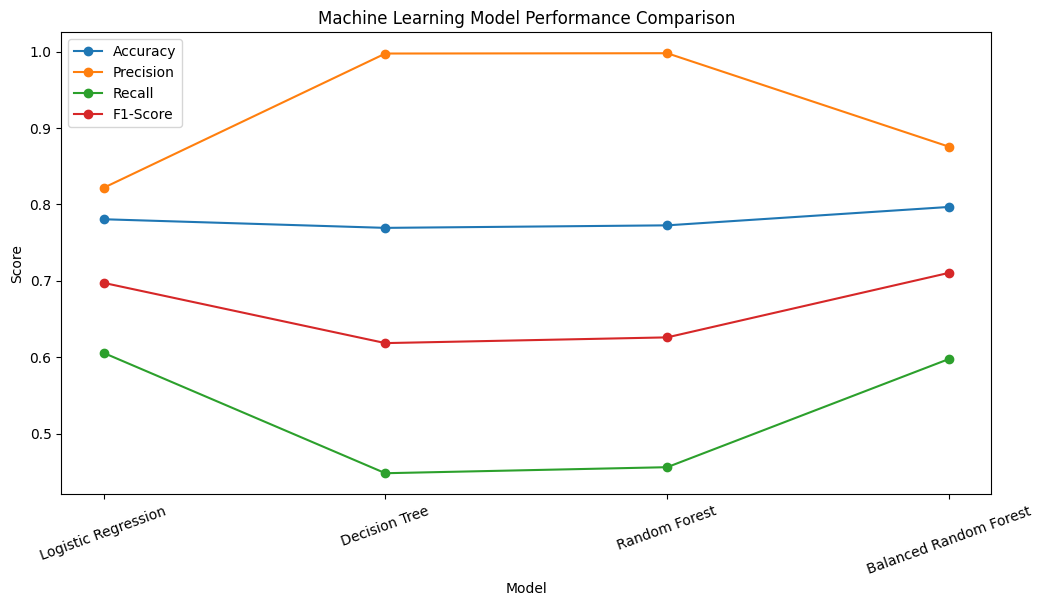

In [21]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Set the model names
models = model_comparison['Model']

# Create the figure
plt.figure(figsize=(12, 6))

# Plot each evaluation metric
plt.plot(models, model_comparison['Accuracy'], marker='o', label='Accuracy')
plt.plot(models, model_comparison['Precision'], marker='o', label='Precision')
plt.plot(models, model_comparison['Recall'], marker='o', label='Recall')
plt.plot(models, model_comparison['F1-Score'], marker='o', label='F1-Score')

# Add chart title and labels
plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')

# Display the legend
plt.legend()

# Rotate model names for readability
plt.xticks(rotation=20)

# Display the chart
plt.show()

In [23]:
# Check which machine learning objects are still available
print("preprocessor:", 'preprocessor' in globals())
print("random_forest_balanced:", 'random_forest_balanced' in globals())
print("X_train_processed:", 'X_train_processed' in globals())
print("y_pred_rf_balanced:", 'y_pred_rf_balanced' in globals())

preprocessor: False
random_forest_balanced: False
X_train_processed: False
y_pred_rf_balanced: False


In [24]:
# Define the final features used for machine learning
selected_features = [
    'LeadTime',
    'ArrivalDateYear',
    'ArrivalDateMonth',
    'StaysInWeekendNights',
    'StaysInWeekNights',
    'TotalStayNights',
    'Adults',
    'Children',
    'Babies',
    'Meal',
    'Country',
    'MarketSegment',
    'DistributionChannel',
    'IsRepeatedGuest',
    'PreviousCancellations',
    'PreviousBookingsNotCanceled',
    'ReservedRoomType',
    'DepositType',
    'CustomerType',
    'ADR',
    'RequiredCarParkingSpaces'
]

# Create the feature matrix
X = df[selected_features]

# Create the target variable
y = df['IsCanceled']

# Display the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (79330, 21)
y shape: (79330,)


In [25]:
# Import the required preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Handle missing values
X = X.copy()
X['Children'] = X['Children'].fillna(0)
X['Country'] = X['Country'].fillna('Unknown')

# Define numerical features
numerical_features = [
    'LeadTime',
    'ArrivalDateYear',
    'StaysInWeekendNights',
    'StaysInWeekNights',
    'TotalStayNights',
    'Adults',
    'Children',
    'Babies',
    'IsRepeatedGuest',
    'PreviousCancellations',
    'PreviousBookingsNotCanceled',
    'ADR',
    'RequiredCarParkingSpaces'
]

# Define categorical features
categorical_features = [
    'ArrivalDateMonth',
    'Meal',
    'Country',
    'MarketSegment',
    'DistributionChannel',
    'ReservedRoomType',
    'DepositType',
    'CustomerType'
]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Fit the preprocessor on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the testing data
X_test_processed = preprocessor.transform(X_test)

# Display the resulting shapes
print("Training data:", X_train_processed.shape)
print("Testing data:", X_test_processed.shape)

Training data: (63464, 218)
Testing data: (15866, 218)


In [26]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_logistic[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0]


In [27]:
# Import the evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

# Display the results
print("Logistic Regression")
print("Accuracy:", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall:", round(recall_logistic, 4))
print("F1-Score:", round(f1_logistic, 4))

Logistic Regression
Accuracy: 0.7807
Precision: 0.822
Recall: 0.6054
F1-Score: 0.6973


In [28]:
# Import the Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_processed, y_train)

# Generate predictions
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Display the first 20 predictions
print(y_pred_tree[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]


In [29]:
# Calculate the evaluation metrics for the Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Display the results
print("Decision Tree")
print("Accuracy:", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall:", round(recall_tree, 4))
print("F1-Score:", round(f1_tree, 4))

Decision Tree
Accuracy: 0.7693
Precision: 0.9976
Recall: 0.448
F1-Score: 0.6184


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

# Generate predictions
y_pred_rf = random_forest_model.predict(X_test_processed)

print(y_pred_rf[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]


In [31]:
# Calculate the evaluation metrics for the Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display the results
print("Random Forest")
print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-Score:", round(f1_rf, 4))

Random Forest
Accuracy: 0.7715
Precision: 0.998
Recall: 0.4533
F1-Score: 0.6235


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Create a balanced Random Forest model
random_forest_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_balanced.fit(X_train_processed, y_train)

# Generate predictions
y_pred_rf_balanced = random_forest_balanced.predict(X_test_processed)

print(y_pred_rf_balanced[:20])

[0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0]


In [33]:
# Calculate the evaluation metrics for the Balanced Random Forest
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)
precision_rf_balanced = precision_score(y_test, y_pred_rf_balanced)
recall_rf_balanced = recall_score(y_test, y_pred_rf_balanced)
f1_rf_balanced = f1_score(y_test, y_pred_rf_balanced)

# Display the results
print("Balanced Random Forest")
print("Accuracy:", round(accuracy_rf_balanced, 4))
print("Precision:", round(precision_rf_balanced, 4))
print("Recall:", round(recall_rf_balanced, 4))
print("F1-Score:", round(f1_rf_balanced, 4))

Balanced Random Forest
Accuracy: 0.7962
Precision: 0.8723
Recall: 0.5994
F1-Score: 0.7105


In [34]:
# Create a comparison table for all machine learning models
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Balanced Random Forest'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_rf_balanced
    ],
    'Precision': [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_rf_balanced
    ],
    'Recall': [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_rf_balanced
    ],
    'F1-Score': [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_rf_balanced
    ]
})

# Display the comparison table
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7807,0.8220,0.6054,0.6973
1,Decision Tree,0.7693,0.9976,0.4480,0.6184
2,Random Forest,0.7715,0.9980,0.4533,0.6235
3,Balanced Random Forest,0.7962,0.8723,0.5994,0.7105


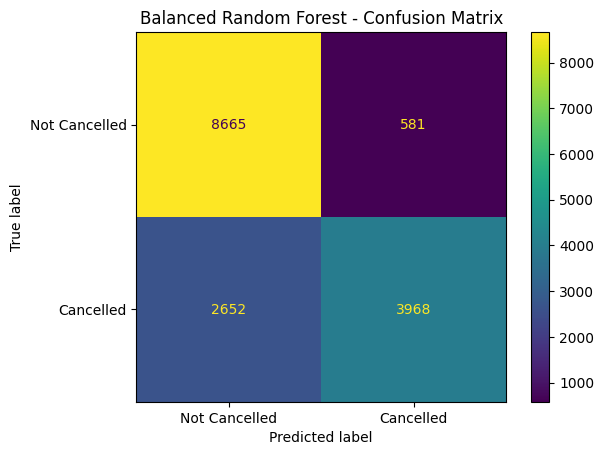

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_balanced)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Cancelled', 'Cancelled']
)

disp.plot()
plt.title('Balanced Random Forest - Confusion Matrix')
plt.show()

In [36]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from the Balanced Random Forest
feature_importance = random_forest_balanced.feature_importances_

# Create a DataFrame with feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 15 features
importance_df.head(15)

,Feature,Importance
211,categorical__DepositType_No Deposit,0.198782
212,categorical__DepositType_Non Refund,0.168064
154,categorical__Country_PRT,0.115663
0,numerical__LeadTime,0.077568
9,numerical__PreviousCancellations,0.066071
194,categorical__MarketSegment_Groups,0.038061
196,categorical__MarketSegment_Online TA,0.033126
217,categorical__CustomerType_Transient-Party,0.027464
216,categorical__CustomerType_Transient,0.026333
11,numerical__ADR,0.022178


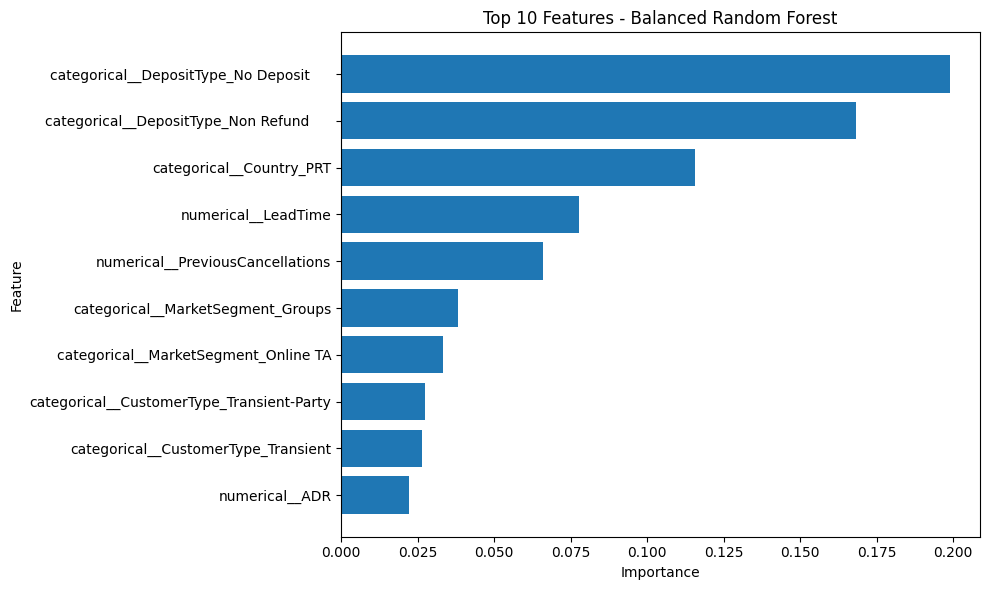

In [37]:
import matplotlib.pyplot as plt

# Select the top 10 most important features
top_features = importance_df.head(10).sort_values(
    by='Importance',
    ascending=True
)

# Create the feature importance chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features - Balanced Random Forest')

plt.tight_layout()
plt.show()

In [ ]:
## Machine Learning Results and Discussion

Four classification models were evaluated to predict whether a hotel booking would be cancelled: Logistic Regression, Decision Tree, Random Forest, and Balanced Random Forest.

The models were evaluated using Accuracy, Precision, Recall, and F1-Score. The Balanced Random Forest achieved an accuracy of 79.62% and an F1-Score of 71.05% in the test set. Logistic Regression achieved a slightly higher Recall of 60.54%, compared with 59.94% for the Balanced Random Forest.

The results show a trade-off between Precision and Recall across the models. The Decision Tree and standard Random Forest achieved very high Precision but lower Recall, meaning that they identified fewer of the actual cancelled bookings. The Balanced Random Forest identified a larger proportion of cancelled bookings while maintaining a higher overall F1-Score than the other tested models.

The confusion matrix for the Balanced Random Forest showed 3,968 correctly identified cancelled bookings and 2,652 cancelled bookings that were incorrectly classified as non-cancelled. The model also correctly identified 8,665 non-cancelled bookings, while 581 non-cancelled bookings were classified as cancelled.

Feature importance analysis showed that Deposit Type, Country, Lead Time, and Previous Cancellations were among the features that contributed most to the Balanced Random Forest's predictions. These results indicate that information available at the time of booking can provide useful signals for predicting cancellation behaviour.

Feature importance should be interpreted as a contribution to the model's predictions rather than as evidence of a causal relationship.

In [ ]:
# Hotel Booking Cancellation Dashboard

This dashboard provides an overview of hotel booking cancellations and presents key findings from the exploratory data analysis and machine learning models.

In [39]:
# Calculate key dashboard indicators
total_bookings = len(df)
total_cancelled = df['IsCanceled'].sum()
cancellation_rate = (total_cancelled / total_bookings) * 100
average_lead_time = df['LeadTime'].mean()

print("Hotel Booking Cancellation Dashboard")
print("-------------------------------------")
print("Total Bookings:", total_bookings)
print("Cancelled Bookings:", total_cancelled)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Average Lead Time:", round(average_lead_time, 2), "days")

Hotel Booking Cancellation Dashboard
-------------------------------------
Total Bookings: 79330
Cancelled Bookings: 33102
Cancellation Rate: 41.73 %
Average Lead Time: 109.74 days


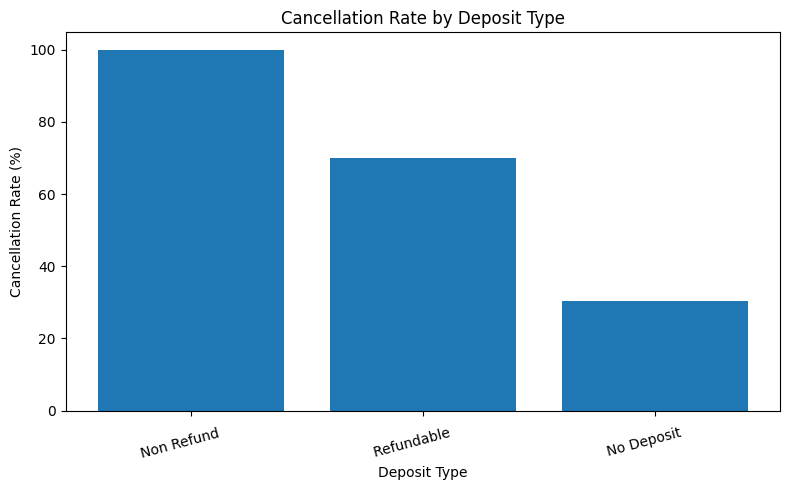

In [40]:
import matplotlib.pyplot as plt

# Calculate cancellation rate by deposit type
deposit_cancellation = (
    df.groupby('DepositType')['IsCanceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Create the chart
plt.figure(figsize=(8, 5))

plt.bar(
    deposit_cancellation.index,
    deposit_cancellation.values
)

plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Deposit Type')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

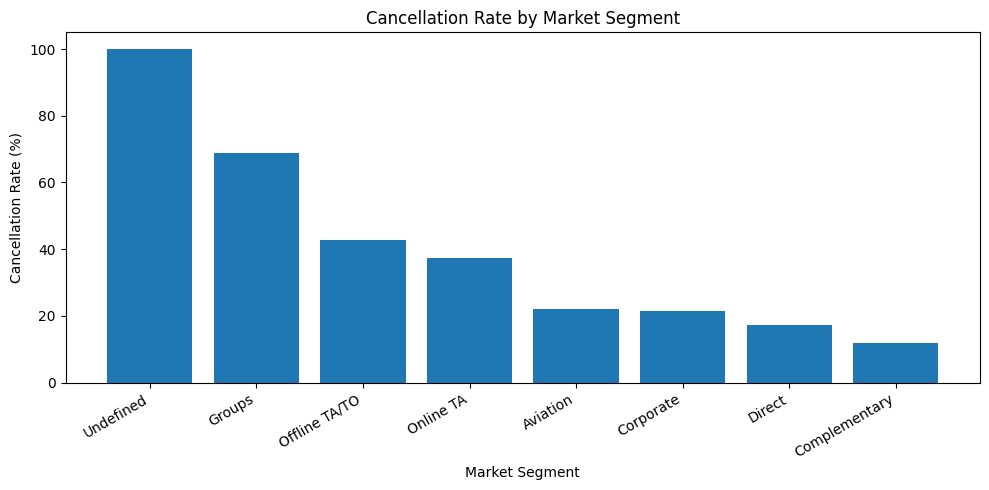

In [41]:
# Calculate cancellation rate by market segment
market_cancellation = (
    df.groupby('MarketSegment')['IsCanceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Create the chart
plt.figure(figsize=(10, 5))

plt.bar(
    market_cancellation.index,
    market_cancellation.values
)

plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Market Segment')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

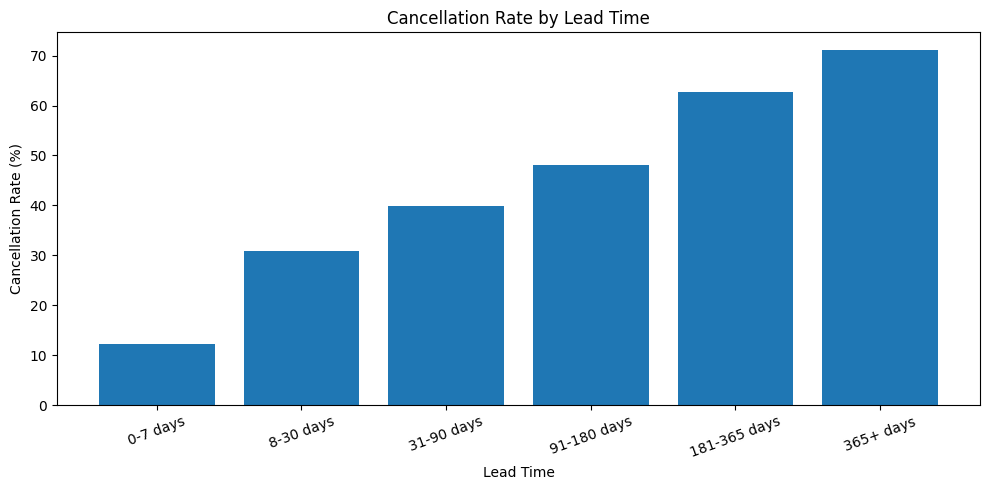

In [42]:
# Create lead time groups
lead_time_bins = [0, 7, 30, 90, 180, 365, float('inf')]
lead_time_labels = [
    '0-7 days',
    '8-30 days',
    '31-90 days',
    '91-180 days',
    '181-365 days',
    '365+ days'
]

df['LeadTimeGroup'] = pd.cut(
    df['LeadTime'],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True
)

# Calculate cancellation rate by lead time group
lead_time_cancellation = (
    df.groupby('LeadTimeGroup', observed=True)['IsCanceled']
    .mean()
    .mul(100)
)

# Create the chart
plt.figure(figsize=(10, 5))

plt.bar(
    lead_time_cancellation.index,
    lead_time_cancellation.values
)

plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Lead Time')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

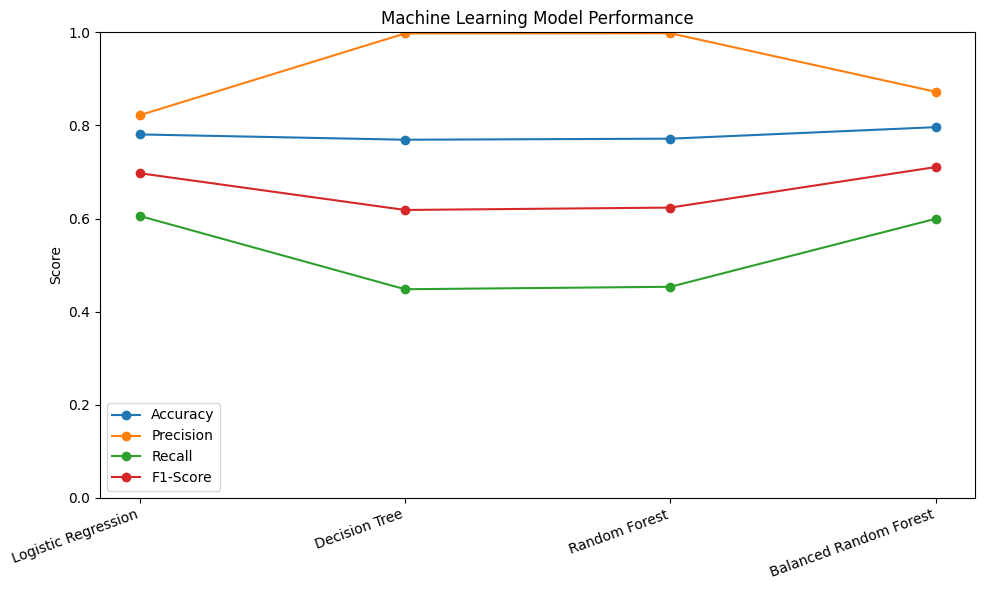

In [43]:
# Create a model performance chart
plt.figure(figsize=(10, 6))

x = range(len(model_comparison))

plt.plot(x, model_comparison['Accuracy'], marker='o', label='Accuracy')
plt.plot(x, model_comparison['Precision'], marker='o', label='Precision')
plt.plot(x, model_comparison['Recall'], marker='o', label='Recall')
plt.plot(x, model_comparison['F1-Score'], marker='o', label='F1-Score')

plt.xticks(
    x,
    model_comparison['Model'],
    rotation=20,
    ha='right'
)

plt.ylabel('Score')
plt.title('Machine Learning Model Performance')
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Dashboard Insights

The analysis identified several patterns in hotel booking cancellations.

- The overall cancellation rate in the dataset was 41.73%.
- Cancellation rates varied considerably across deposit types, with Non Refund bookings showing the highest observed cancellation rate.
- Market Segment also showed differences in cancellation rates, particularly for Group and Offline TA/TO bookings.
- Cancellation rates increased across the Lead Time groups, with bookings made more than 365 days in advance showing a higher observed cancellation rate than bookings made within one week of arrival.
- Machine learning models showed that Deposit Type, Country, Lead Time, and Previous Cancellations were among the most important features used by the Balanced Random Forest.
- The Balanced Random Forest achieved an accuracy of 79.62% and an F1-Score of 71.05% on the test set.

These findings suggest that booking characteristics available at the time of reservation can provide useful information for predicting cancellation behaviour.